Усі імпорти рекомендую розташувати отут зверху для зручності.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

1.Завантажте дані у pandas dataframe з файла `ecommerce_data.csv`. Обовʼязково при завантаженні вкажіть параметр `encoding = 'ISO-8859-1'`, без нього буде помилка.

In [41]:
df = pd.read_csv('ecommerce_data_1.csv', encoding='ISO-8859-1')

2.Виведіть перші три записи в завантаженому наборі даних

In [42]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


3.Перейменуйте колонки, для цього просто запустіть код нижче та зверніть увагу, як ми перейменували колонки. Перейменування тут - просто для зручності.

4.Виведіть поточні назви колонок.

In [43]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

# Базове розуміння даних

5.Виведіть кількість колонок і стовпців в наборі даних.

In [44]:
df.shape

(541909, 8)

6.Виведіть типи даних в кожній з колонок. Будь-яким способом, але аби для Вас як для дослідника стало зрозуміло, з якими даними ми зараз маємо справу.

In [45]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Очікуваний результат (один з):

![](https://drive.google.com/uc?export=view&id=1Pc2cam8vdZeEP4xLXlsoevOTt4O_KI4R)

7.Виведіть кількість пустих (null) значень в кожній з колонок за спаданням цієї кількості.

In [46]:
df.isna().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1IXVowBSH9-LtCR8gkMXcQHXWPinujkF5)

### Конвертація дат

8.Конвертуйте дату колонки `invoicedate` у тип `datetime64[ns]`.

In [47]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors="coerce").astype("datetime64[ns]")
df['InvoiceDate'].dtype

dtype('<M8[ns]')

Запустіть код нижче:

In [48]:
df.InvoiceDate[:2]

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1ds5CwdM5D50hlnk1zsDw7YT-aG_KErIg)

# Чистка даних

### Прибираємо пусті значення (NA)

9.Приберіть усі пусті значення з набору даних `df` і запишіть результат у нову змінну `df_new`.

In [49]:
df_new = df.dropna()
print(f"Було рядків: {len(df)}")
print(f"Стало рядків: {len(df_new)}")
print(f"Видалено: {len(df) - len(df_new)}")

Було рядків: 541909
Стало рядків: 406829
Видалено: 135080


10.Виведіть кількість колонок і рядків в `df_new`.

In [50]:
df_new.shape

(406829, 8)

11.Виведіть, який відсоток (від 0 до 100%) рядків ми видалили з `df`, коли прибрали пусті значення? Округліть результат до цілих відсотків.

In [51]:
removed_pct = round((1 - len(df_new) / len(df)) * 100)
print(f"{removed_pct}%")

25%


Очікуваний результат: `25%`

### Приберемо негативні значення `quantity`

12.Виведіть мінімальне, максимальне і середнє значення колонки `quantity`. Найкраще згадати, як це зробити одною командою, що дозволяє "описати" колонки в датафреймі :)

In [52]:
df_new['Quantity'].describe()

count    406829.000000
mean         12.061303
std         248.693370
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

13.Скажімо, нас не цікавлять записи з негативними quantity (бо це поверненння).   
Приберіть всі рядки, де `quantity` менше 0 з набора даних `df_new` і запишіть в той самий набір даних `df_new`.

In [53]:
df_new = df_new[df_new['Quantity'] >= 0]
df_new['Quantity'].describe()

count    397924.000000
mean         13.021823
std         180.420210
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

# Обробка даних

### Зміна типу даних `custid`

14.Ідентифікатор клієнта має мати тип "рядок" для простоти роботи з цією колонкою. Бо інакше пандас буде інтерпретувати цю колонку як число - а це логічно не правильно.
Перетворіть тип даних колонки `custid`  спочатку на int, а потім на рядок. Або можете зробити ці перетворення в одній функції (лямбді).

In [54]:
df_new['CustomerID'] = df_new['CustomerID'].apply(lambda x: str(int(x)))

Запустіть код нижче:

In [55]:
df_new['CustomerID'][:3]

0    17850
1    17850
2    17850
Name: CustomerID, dtype: str

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1V5Mn0OC6hD-OmXGswe2N8CsIxsuBuoPE)

### Додамо колонку `amountspent`

15.Додайте в `df_new` колонку `amountspent`, яка є добутком колонок `quantity` і `unitprice`.

In [56]:
df_new['AmountSpent'] = df_new['Quantity'] * df_new['UnitPrice']
df_new.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,AmountSpent
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00


### Додавання колонок `month`, `day`, `hour`, `yearmonth` для інвойса.

16.Використовуючи колонку invoicedate та те, що вона в нас вже має тип datetime, створіть 4 нових колонки в даних:
- `yearmonth` - рік і місяць інвойсу разом у форматі "2010-12" - тобто 12 місяць 2010го року і тип цієї колонки має бути датою (підказка: просто робимо для колонки`invoicedate` `dt.to_period('M')` для того аби таке отримати)
- `month` - місяць інвойсу
- `day` - день тижня інвойсу (понеділок - це перший, неділя - останній)
- `hour` - година інвойсу

Зробіть також так, аби `yearmonth` була третьою (за рахунком) колонкою в датафреймі, `month` - четвертою, `day` - пʼятою, `hour` - шостою.

In [57]:
df_new['yearmonth'] = df_new['InvoiceDate'].dt.to_period('M')
df_new['month'] = df_new['InvoiceDate'].dt.month
df_new['day'] = df_new['InvoiceDate'].dt.dayofweek + 1  # 1=понеділок, 7=неділя
df_new['hour'] = df_new['InvoiceDate'].dt.hour

cols = list(df_new.columns[:2]) + ['yearmonth', 'month', 'day', 'hour'] + list(df_new.columns[2:-4])
df_new = df_new[cols]

Запустіть код нижче:

In [58]:
df_new.head(3)

,InvoiceNo,StockCode,yearmonth,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,AmountSpent
0,536365,85123A,2010-12,12,3,8,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,2010-12,12,3,8,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,2010-12,12,3,8,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00


In [59]:
df_new.dtypes

InvoiceNo                 str
StockCode                 str
yearmonth           period[M]
month                   int32
day                     int32
hour                    int32
Description               str
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID                str
Country                   str
AmountSpent           float64
dtype: object

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1Wn4tNmFOvqHk0VLpfwASKWiPpjJ5_Jgt)

![](https://drive.google.com/uc?export=view&id=1fYm7_uYhk14J51YkqJLtsQo_aqxz6jGZ)

# Базовий Exploratory Data Analysis (EDA)

17.Побудуйте з допомогою методів візуалізації `pandas` датафрейму (ті що з категорії `df.plot()`) стовпчастий графік кількості унікальних продажів помісячно за весь наявний період в даних. Зробіть так, аби підписи дат були нахилені під кутом 45 градусів для зручнішого перегляду.
Кількість унікальних продажів - це кількість унікальних інвойсів.

Підказка: для візуалізації нам спочатку треба агреугувати дані помісячно.

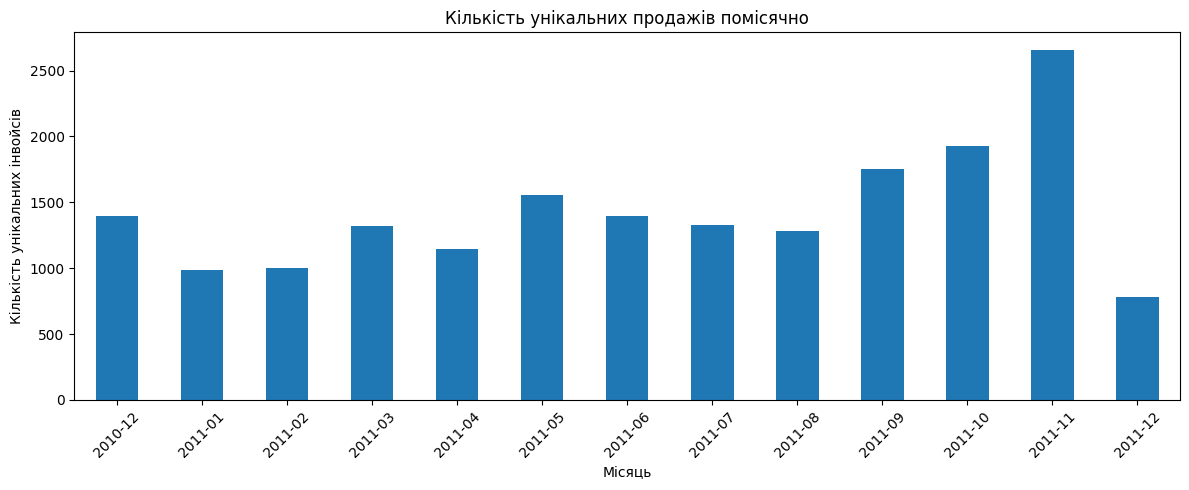

In [61]:
monthly_sales = df_new.groupby('yearmonth')['InvoiceNo'].nunique()

monthly_sales.plot(
    kind='bar',
    figsize=(12, 5),
    title='Кількість унікальних продажів помісячно'
)

plt.xlabel('Місяць')
plt.ylabel('Кількість унікальних інвойсів')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1xbjqTCroVKLgdRxFGA9LG1T6Xx9eWlO1)

18.Побудуйте стовпчастий графік кількості унікальних інвойсів для топ 10 клієнтів за цим показником.

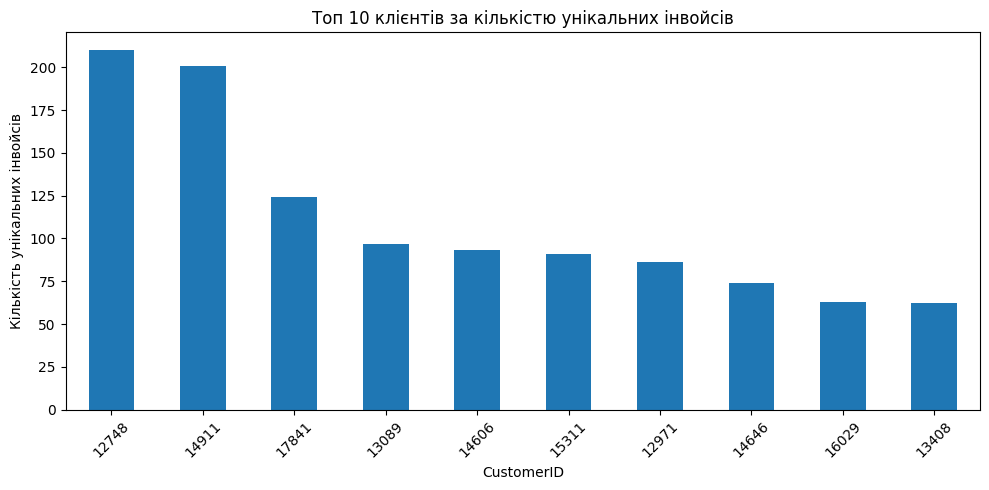

In [63]:
top10_customers = df_new.groupby('CustomerID')['InvoiceNo'].nunique().nlargest(10)

top10_customers.plot(
    kind='bar',
    figsize=(10, 5),
    title='Топ 10 клієнтів за кількістю унікальних інвойсів'
)

plt.xlabel('CustomerID')
plt.ylabel('Кількість унікальних інвойсів')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1zGhcVaPZBqcKj8YG_P-0pOzGVAV8cJNr)

19.Створіть новий датафрейм, що містить сумарний `amountspent` по кожному ідентифікатору клієнта.

In [65]:
customer_spending = df_new.groupby('CustomerID')['AmountSpent'].sum().reset_index()
customer_spending.head(3)

,CustomerID,AmountSpent
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24


20.Використовуючи датафрейм з попереднього пункту, виведіть, якими є 10, 25, 50, 75 і 90 персентилі сумарних витрат клієнтів за розглянутий період:

In [69]:
customer_spending.describe(percentiles=[.1, .25, .5, .75, .9])

,AmountSpent
count,4339.000000
mean,2053.793018
std,8988.248381
min,0.000000
10%,156.566000
25%,307.245000
50%,674.450000
75%,1661.640000
90%,3646.164000
max,280206.020000


Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=16h2lsEwR3GooNkzH0JLfJHRk5oyG3ZqE)

21.Скільки унікальних клієнтів мають сумарні витрати вищі, ніж 90-тий персентиль в попередньому завдані?

In [72]:
quantile_90 = customer_spending['AmountSpent'].quantile(0.9)

top_customers = customer_spending[customer_spending['AmountSpent'] > quantile_90]

count_top_customers = top_customers.shape[0]

print(f"Значення 90-го персентиля: {quantile_90:.2f}")
print(f"Кількість клієнтів з витратами понад це значення: {count_top_customers}")

Значення 90-го персентиля: 3646.16
Кількість клієнтів з витратами понад це значення: 434


22.Виведіть середню суму покупок в мережі по дням тижня. Дні тижня мають йти в звичному порядку Monday, Tuesday і т.д.

In [74]:
day_names = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 
             5: 'Friday', 6: 'Saturday', 7: 'Sunday'}

df_new.groupby('day')['AmountSpent'].mean() \
      .rename(index=day_names) \
      .reindex(day_names.values())

day
Monday       21.065755
Tuesday      25.582686
Wednesday    23.056790
Thursday     24.694687
Friday       27.098468
Saturday           NaN
Sunday       12.624679
Name: AmountSpent, dtype: float64

## Дослідимо продажі на суму 0 умовних одиниць

23.Можна було помітити вище, що в нас є продажі на суму 0. Дослідимо їх. Створіть новий датафрейм з тільки такими продажами.

In [81]:
df_zero = df_new[df_new['AmountSpent'] == 0]
print(len(df_zero))
df_zero.head()

40


,InvoiceNo,StockCode,yearmonth,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,AmountSpent
9302,537197,22841,2010-12,12,7,14,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647,Germany,0.0
33576,539263,22580,2010-12,12,4,14,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560,United Kingdom,0.0
40089,539722,22423,2010-12,12,2,13,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911,EIRE,0.0
47068,540372,22090,2011-01,1,4,16,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081,United Kingdom,0.0
47070,540372,22553,2011-01,1,4,16,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081,United Kingdom,0.0


### Динаміка продажів на суму 0

24.Зобразіть у вигляді стовпчастої діаграми помісячну динаміку продажів на суму 0.

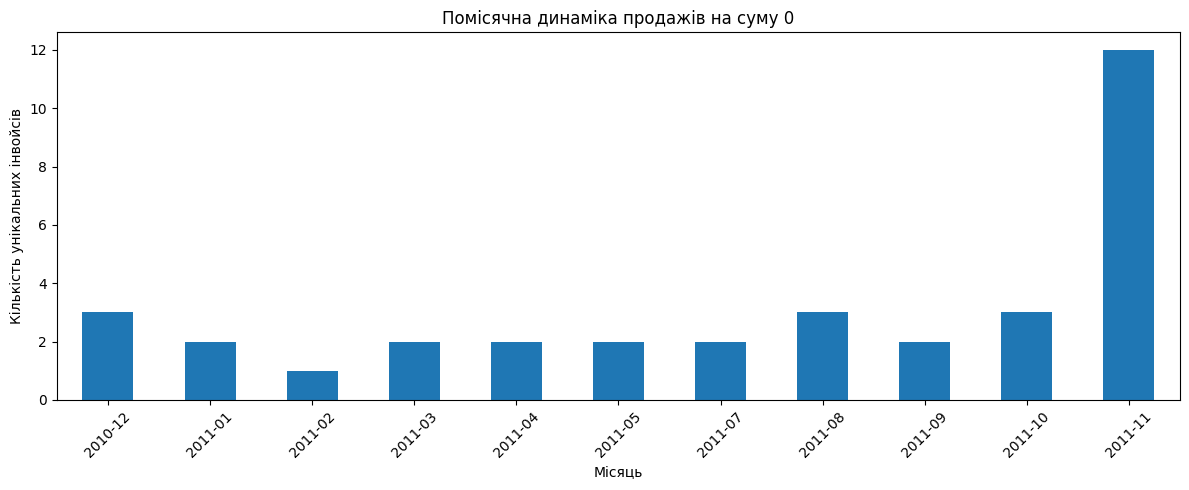

In [82]:
df_zero.groupby(df_zero['yearmonth'].astype(str))['InvoiceNo'].nunique().plot(
    kind='bar',
    figsize=(12, 5),
    title='Помісячна динаміка продажів на суму 0'
)

plt.xlabel('Місяць')
plt.ylabel('Кількість унікальних інвойсів')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1RfpdWGqkOmwZ6RVUqQz-U-q3qkml5g88)

25.Згрупуйте дані за країнами та підрахуйте кількість унікальних інвойсів з сумою 0 для кожної країни. Виведіть у вигляді датафрейму.

In [83]:
df_zero.groupby('Country')['InvoiceNo'].nunique().reset_index() \
       .sort_values('InvoiceNo', ascending=False)

,Country,InvoiceNo
9,United Kingdom,21
0,Australia,3
1,EIRE,2
3,Germany,2
4,Netherlands,1
2,France,1
5,Norway,1
6,RSA,1
7,Spain,1
8,Switzerland,1


Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1N9rcWby_Umc31Q7e-1p2bCb1nCpzadoz)

Велике питання, чого магазин так багато порівняно роздавав безкоштовних товарів в UK, але така політика фірми :)

Якщо у вас ще є натхнення, пропоную задати до цих даних ще 3 своїх питання.